In [1]:
import pandas as pd

df = pd.read_csv(
    "voles_giant.edges",
    sep=" ",
    header=None,
    names=["source", "target"]
)

df.head()

,source,target
0,3,4
1,3,5
2,3,6
3,3,7
4,3,8


# Assigment 1

In [2]:
import numpy as np


D = {}  # grado de cada nodo

with open("voles_giant.edges") as f:
    for line in f:
        parts = line.strip().split()
        u, v = int(parts[0]), int(parts[1])
        D[u] = D.get(u, 0) + 1
        D[v] = D.get(v, 0) + 1


# Mapear nodos a índices 0..N-1
nodes = sorted(D.keys())
N = len(nodes)
node_to_idx = {n: i for i, n in enumerate(nodes)}
degrees = np.array([D[n] for n in nodes], dtype=int)

E = degrees.sum() // 2  # número de aristas (cada una cuenta dos veces)
print(f"N = {N}, E = {E}")

# Inizializar V con el tamaño total de vecinos (2 * E) y punteros
V = np.zeros(2 * E, dtype=int)

# Puntero 1: primera posición en V para los vecinos de cada nodo
ptr1 = np.zeros(N, dtype=int)
ptr1[0] = 0
for i in range(1, N):
    ptr1[i] = ptr1[i-1] + degrees[i-1]

# Puntero 2 (móvil): se inicializa igual que ptr1 y avanza al añadir vecinos
ptr2 = ptr1.copy()

# rellenar V
with open("voles_giant.edges") as f:
    for line in f:
        parts = line.strip().split()
        u, v = int(parts[0]), int(parts[1])
        i, j = node_to_idx[u], node_to_idx[v]

        V[ptr2[i]] = j
        ptr2[i] += 1

        V[ptr2[j]] = i
        ptr2[j] += 1

# VERIFICACIÓN
E_check = degrees.sum() // 2
avg_degree = degrees.mean()

print(f"Nodos:        {N}")
print(f"Aristas:      {E_check}")
print(f"Grado medio:  {avg_degree:.4f}")
print()
print("node degree")
for i, n in enumerate(nodes):
    print(f"{n} {degrees[i]}")



N = 1613, E = 4562
Nodos:        1613
Aristas:      4562
Grado medio:  5.6565

node degree
3 5
4 4
5 6
6 10
7 2
8 4
9 2
10 3
11 6
12 7
13 12
14 12
15 11
16 12
17 9
18 2
19 6
20 14
21 1
22 3
23 4
24 8
25 2
26 5
27 10
28 8
29 8
30 14
31 10
32 2
33 3
34 2
35 1
36 3
37 4
38 3
39 4
40 5
41 1
42 2
43 8
44 5
45 1
46 1
47 8
48 1
49 1
50 6
51 11
52 3
53 5
54 7
55 22
56 5
57 8
58 2
59 7
60 3
61 1
62 1
63 4
64 8
65 1
66 2
67 6
68 4
69 1
70 4
71 1
72 2
73 3
74 3
75 5
76 11
77 3
78 10
79 3
80 5
81 24
82 4
83 11
84 8
85 4
86 4
87 5
88 2
89 6
90 5
91 3
92 5
93 2
94 18
95 5
96 22
97 2
98 1
99 3
100 7
101 6
104 2
105 4
106 6
109 17
110 2
111 2
112 4
113 3
114 1
115 2
116 2
117 1
118 2
119 5
120 3
121 2
122 4
123 2
124 3
125 2
126 4
127 3
128 1
129 1
130 2
131 8
132 21
133 3
134 11
135 2
136 1
137 4
138 2
139 2
140 6
141 10
142 4
143 10
144 10
145 10
146 1
147 3
148 2
149 2
150 10
151 4
152 1
155 5
156 17
157 2
158 1
159 9
160 6
161 4
162 5
163 3
164 15
165 9
166 12
167 36
168 7
169 3
170 3
171 7
172 5


In [3]:
nodo = 5
i = node_to_idx[nodo]
vecinos_idx = V[ptr1[i] : ptr1[i] + degrees[i]]
vecinos = [nodes[j] for j in vecinos_idx]
print(f"Vecinos de {nodo}: {vecinos}")

Vecinos de 5: [3, 4, 6, 8, 14, 26]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#P(k): histograma de grados
k_max = degrees.max()

# Conteo de ocurrencias de cada grado
pk_count = np.zeros(k_max + 1, dtype=int)
for d in degrees:
    pk_count[d] += 1

# P(k) normalizado
pk = pk_count / N

# P(k) acumulado: P(K <= k)
pk_cum = np.zeros(k_max + 1, dtype=float)
for k in range(k_max + 1):
    pk_cum[k] = pk_cum[k-1] + pk[k] if k > 0 else pk[0]

# k_nn(k): grado medio de los vecinos de nodos con grado k
k_nn = np.zeros(k_max + 1, dtype=float)

for i in range(N):
    ki = degrees[i]
    if ki == 0:
        continue
    # Contribución de cada vecino al k_nn(ki)
    # Normalizado por ki (grado del nodo) y por pk_count[ki] (nodos en clase k)
    for pos in range(ptr1[i], ptr1[i] + ki):
        j = V[pos]
        kj = degrees[j]
        k_nn[ki] += kj / (ki * pk_count[ki])

# --- Resultados ---
print(f"{'k':>6}  {'P(k)':>10}  {'P_cum(k)':>10}  {'k_nn(k)':>10}")
print("-" * 45)
for k in range(k_max + 1):
    if pk[k] > 0:
        print(f"{k:>6}  {pk[k]:>10.6f}  {pk_cum[k]:>10.6f}  {k_nn[k]:>10.4f}")



     k        P(k)    P_cum(k)     k_nn(k)
---------------------------------------------
     1    0.115313    0.115313     10.0430
     2    0.141971    0.257285      8.9105
     3    0.139492    0.396776      9.6015
     4    0.133912    0.530688      9.6030
     5    0.090515    0.621203     10.0411
     6    0.079975    0.701178     10.0543
     7    0.063236    0.764414     10.6681
     8    0.052077    0.816491      9.1012
     9    0.046497    0.862988     10.3215
    10    0.020459    0.883447      9.9939
    11    0.022939    0.906386      9.5233
    12    0.015499    0.921885      9.9467
    13    0.012399    0.934284     10.3731
    14    0.010539    0.944823     10.3487
    15    0.010539    0.955363      9.6039
    16    0.005580    0.960942     11.5000
    17    0.004960    0.965902     10.5221
    18    0.004340    0.970242     10.5317
    19    0.002480    0.972722      9.2237
    20    0.004340    0.977061      9.7071
    21    0.004960    0.982021     10.2679
    22  

In [44]:
from scipy import stats

ks_nn = np.where(k_nn > 0)[0]
log_k = np.log(ks_nn)
log_y = np.log(k_nn[ks_nn] / ks_nn)

slope, intercept, r, p, se = stats.linregress(log_k, log_y)
print(f"Pendiente (−α): {slope:.3f}, R² = {r**2:.3f}")



Pendiente (−α): -0.989, R² = 0.993


In [35]:
import networkx as nx

G_giant = nx.Graph()
with open("voles_giant.edges") as f:
    for line in f:
        parts = line.strip().split()
        u, v = int(parts[0]), int(parts[1])
        G_giant.add_edge(u, v)

r = nx.degree_assortativity_coefficient(G_giant)
print(f"Assortativity: {r:.4f}")

Assortativity: 0.0133


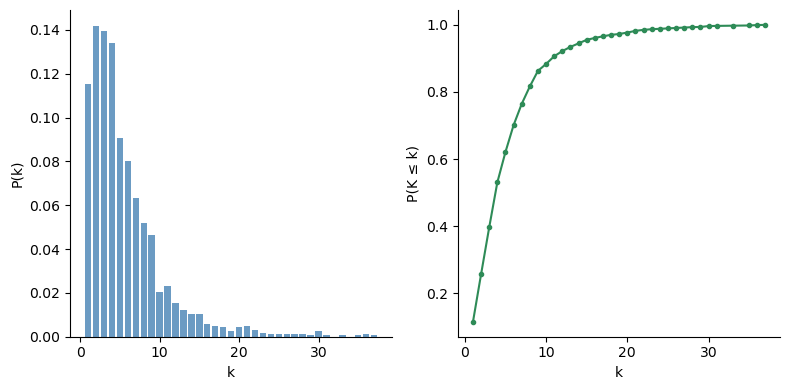

In [103]:
ks = np.where(pk > 0)[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# P(k)
axes[0].bar(ks, pk[ks], color="steelblue", alpha=0.8)
axes[0].set_xlabel("k")
axes[0].set_ylabel("P(k)")
#axes[0].set_title("Degree distribution P(k)")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# P(k) acumulado
axes[1].plot(ks, pk_cum[ks], color="seagreen", marker="o", markersize=3)
axes[1].set_xlabel("k")
axes[1].set_ylabel("P(K ≤ k)")
#axes[1].set_title("Cumulative degree distribution P(k)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("pk_knn.png", dpi=150, bbox_inches="tight")
plt.show()

## Clustering

In [24]:
# --- Clustering coefficient c(k) según la fórmula de la imagen ---
# c(k) = 1 / (k*(k-1)*N_k) * sum_{i in Y(k)} 2*T_i

ck = np.zeros(k_max + 1, dtype=float)

for i in range(N):  # loop 1: sobre cada nodo
    neighbors_list = list(set(V[ptr1[i] : ptr1[i] + degrees[i]]))
    ki = len(neighbors_list)

    if ki < 2:
        continue

    # Precalcular conjuntos de vecinos de cada vecino de i
    neighbors_j_sets = {
        j: set(V[ptr1[j] : ptr1[j] + degrees[j]])
        for j in neighbors_list
    }

    triangles = 0
    for a in range(ki):             # loop 2: primer vecino j
        j = neighbors_list[a]
        for b in range(a + 1, ki):  # loop 3: segundo vecino l
            l = neighbors_list[b]
            if l in neighbors_j_sets[j]:
                triangles += 1

    # Acumular 2*T_i en c(k); el denominador k*(k-1)*N_k se aplica al final
    ck[degrees[i]] += 2 * triangles

# Normalizar c(k) por k*(k-1)*N_k
for k in range(2, k_max + 1):
    if pk_count[k] > 0:
        ck[k] /= k * (k - 1) * pk_count[k]

# Clustering medio global: c_bar = sum_k P(k) * c(k)
avg_cc = sum(pk[k] * ck[k] for k in range(k_max + 1))
print(f"Coeficiente de clustering medio: {avg_cc:.6f}")

# --- Resultados por clase de grado ---
print(f"\n{'k':>6}  {'c(k)':>10}  {'N_k':>6}")
print("-" * 28)
for k in range(k_max + 1):
    if pk[k] > 0:
        print(f"{k:>6}  {ck[k]:>10.6f}  {pk_count[k]:>6}")



Coeficiente de clustering medio: 0.472407

     k        c(k)     N_k
----------------------------
     1    0.000000     186
     2    0.790393     229
     3    0.696296     225
     4    0.641204     216
     5    0.524658     146
     6    0.462016     129
     7    0.461718     102
     8    0.332483      84
     9    0.337037      75
    10    0.307744      33
    11    0.271253      37
    12    0.259394      25
    13    0.237821      20
    14    0.202327      17
    15    0.198880      17
    16    0.221296       9
    17    0.172794       8
    18    0.155929       7
    19    0.103801       4
    20    0.173684       7
    21    0.151786       8
    22    0.132468       5
    23    0.175231       3
    24    0.152174       2
    25    0.138333       2
    26    0.160000       2
    27    0.145299       2
    28    0.096561       2
    29    0.073892       1
    30    0.114943       4
    31    0.124731       1
    33    0.096591       1
    35    0.099160       1
    36    

In [47]:
from scipy.optimize import curve_fit


ks_ck = np.where(ck > 0)[0]
log_k = np.log(ks_ck)
log_c = np.log(ck[ks_ck])
slope_c, intercept_c, r2, _, _ = stats.linregress(log_k, log_c)
print(f"c(k) ~ k^{slope_c:.3f}, R² = {r2**2:.3f}")

c(k) ~ k^-0.805, R² = 0.928


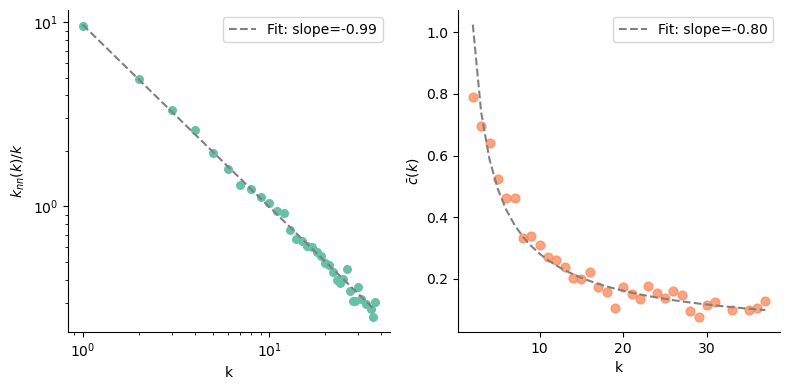

In [104]:
palette = plt.get_cmap("Set2")

ks_ck = np.where(ck > 0)[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
ax= axes[1]
ax.scatter(ks_ck, ck[ks_ck], color=palette(1), alpha=0.8, s=40)
ax.plot(ks_ck, np.exp(intercept_c) * ks_ck**slope_c, color="gray", linestyle="--", label=f"Fit: slope={slope_c:.2f}")
ax.legend()
ax.set_xlabel("k")
ax.set_ylabel(r"$\bar{c}(k)$")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
#ax.set_title(r"Coeficiente de clustering $\bar{c}(k)$")

# k_nn(k)
ks_nn = np.where(k_nn > 0)[0]
axes[0].scatter(ks_nn, k_nn[ks_nn]/ks_nn, color=palette(0), alpha=1, s=30)
axes[0].plot(ks_nn, np.exp(intercept) * ks_nn**slope, color="gray", linestyle="--", label=f"Fit: slope={slope:.2f}")
axes[0].set_xlabel("k")
axes[0].set_ylabel("$k_{nn}(k)/k$")
#axes[0].set_title(" Average nearest neighbor degree $k_{nn}(k)/k$")
axes[0].set_xscale("log") 
axes[0].set_yscale("log") 
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False) 
axes[0].legend()

plt.tight_layout()
plt.savefig("ck.png", dpi=150, bbox_inches="tight")
plt.show()

# comunidades

In [49]:
import networkx as nx

G = nx.Graph()

with open("voles_giant.edges") as f:
    for line in f:
        u, v = map(int, line.split())
        G.add_edge(u, v)

print(G)

Graph with 1613 nodes and 4562 edges


In [50]:
import community as community_louvain

# partition: diccionario nodo -> comunidad
partition_louvain = community_louvain.best_partition(G)

# número de comunidades
num_louvain = len(set(partition_louvain.values()))

print("Número de comunidades:", num_louvain)

Número de comunidades: 18


In [51]:
from collections import Counter

sizes_louvain = Counter(partition_louvain.values())

print("\nTamaño de comunidades:")
for comm, size in sizes_louvain.items():
    print(f"Comunidad {comm}: {size} nodos")


Tamaño de comunidades:
Comunidad 0: 79 nodos
Comunidad 1: 120 nodos
Comunidad 2: 107 nodos
Comunidad 3: 133 nodos
Comunidad 4: 97 nodos
Comunidad 5: 162 nodos
Comunidad 6: 78 nodos
Comunidad 7: 89 nodos
Comunidad 8: 105 nodos
Comunidad 9: 42 nodos
Comunidad 10: 135 nodos
Comunidad 11: 168 nodos
Comunidad 12: 57 nodos
Comunidad 13: 11 nodos
Comunidad 14: 13 nodos
Comunidad 16: 37 nodos
Comunidad 17: 36 nodos
Comunidad 15: 144 nodos


In [52]:
mod_louvain = community_louvain.modularity(partition_louvain, G)

print(f"\nModularidad: {mod_louvain:.4f}")


Modularidad: 0.7806


Número de comunidades: 15

Modularidad: 0.7770


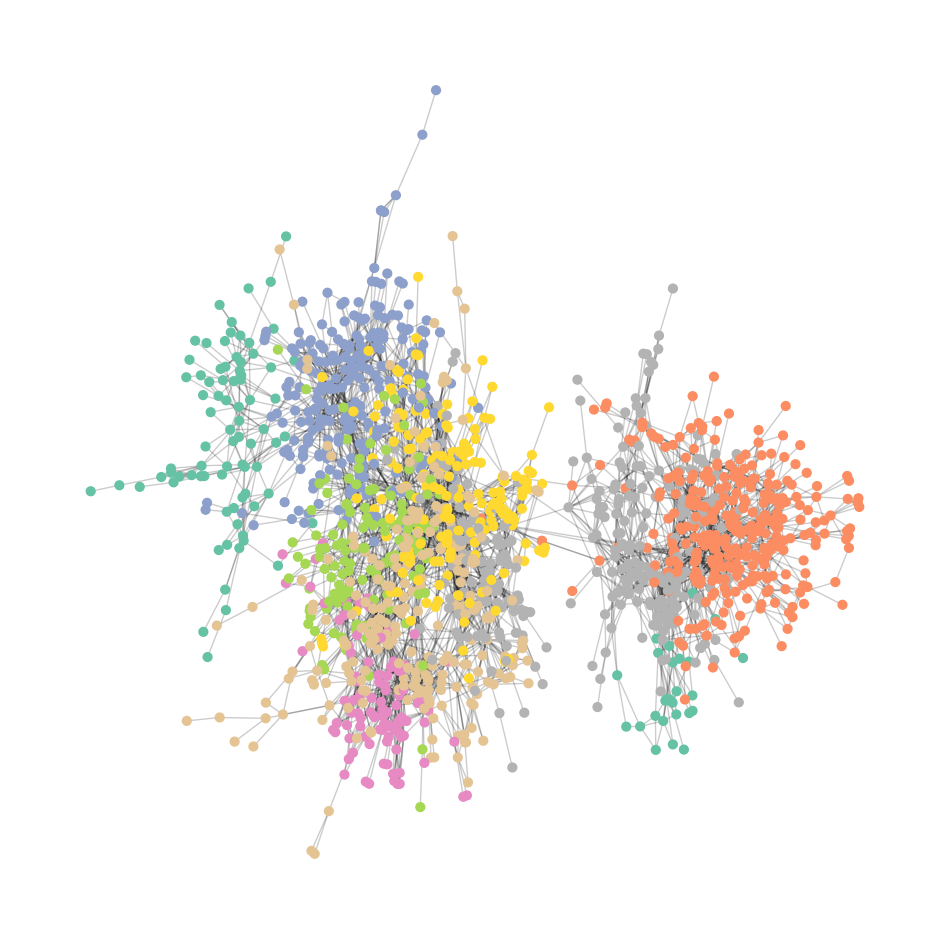

In [56]:
# partition: diccionario nodo -> comunidad
partition_louvain = community_louvain.best_partition(G)

# número de comunidades
num_louvain = len(set(partition_louvain.values()))

print("Número de comunidades:", num_louvain)

mod_louvain = community_louvain.modularity(partition_louvain, G)

print(f"\nModularidad: {mod_louvain:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

# layout del grafo
pos = nx.spring_layout(G, seed=42)

# colores por comunidad
communities = [partition_louvain[node] for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=40,
    node_color=communities,
    cmap=plt.cm.Set2
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

#plt.title("Detección de comunidades (Louvain)")
plt.axis("off")
plt.show()

In [70]:
from collections import defaultdict

import community

ratios_all = []
participation_all = []
modularities = []
n_communities = []

for r in range(100):
    partition = community_louvain.best_partition(G_giant)
    
    # Modularidad y número de comunidades
    modularities.append(community_louvain.modularity(partition, G_giant))
    n_communities.append(len(set(partition.values())))
    
    # k_intra ratio
    ratios_r = []
    participation_r = []
    
    for node in G_giant.nodes():
        comm = partition[node]
        k = G_giant.degree(node)
        if k == 0:
            continue
        
        intra = sum(1 for neigh in G_giant.neighbors(node)
                    if partition[neigh] == comm)
        ratios_r.append(intra / k)
        
        # Participation coefficient
        comm_counts = defaultdict(int)
        for neigh in G_giant.neighbors(node):
            comm_counts[partition[neigh]] += 1
        Y = 1 - sum((cnt / k) ** 2 for cnt in comm_counts.values())
        participation_r.append(Y)
    
    ratios_all.append(np.mean(ratios_r))
    participation_all.append(np.mean(participation_r))

print(f"Comunidades:              {np.mean(n_communities):.1f} ± {np.std(n_communities):.1f}")
print(f"Modularidad Q:            {np.mean(modularities):.4f} ± {np.std(modularities):.4f}")
print(f"Mean k_intra/k ratio:     {np.mean(ratios_all):.4f} ± {np.std(ratios_all):.4f}")
print(f"Mean participation coef:  {np.mean(participation_all):.4f} ± {np.std(participation_all):.4f}")

Comunidades:              16.0 ± 1.0
Modularidad Q:            0.7811 ± 0.0020
Mean k_intra/k ratio:     0.9035 ± 0.0037
Mean participation coef:  0.1323 ± 0.0051


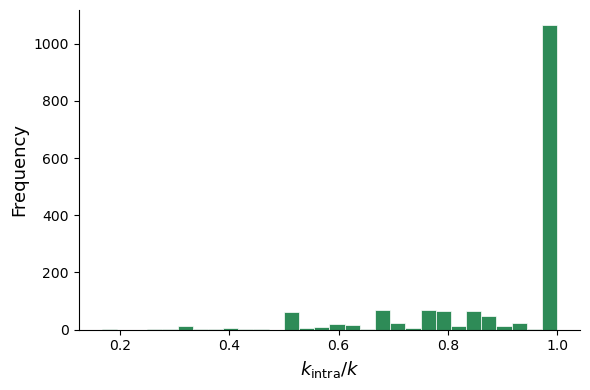

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))

ratios = list(ratio.values())
ax.hist(ratios, bins=30, color="seagreen", edgecolor="white", linewidth=0.5)
ax.set_xlabel(r"$k_{\mathrm{intra}}/k$", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
#ax.set_title("Internal connectivity ratio", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("ratio.png", dpi=150, bbox_inches="tight")
plt.show()

# CM

In [93]:
import numpy as np
import networkx as nx

def generate_cm_network(edge_file, nswap=None):

    # =========================
    # LEER RED ORIGINAL
    # =========================

    G = nx.Graph()

    with open(edge_file) as f:
        for line in f:
            u, v = map(int, line.split())
            G.add_edge(u, v)

    E = G.number_of_edges()

    if nswap is None:
        nswap = E

    # =========================
    # CONFIGURATION MODEL
    # =========================

    G_cm = G.copy()

    nx.double_edge_swap(
        G_cm,
        nswap=10*nswap,
        max_tries=500 * nswap
    )


    nodes = sorted(G_cm.nodes())

    node_to_idx = {
        n: i for i, n in enumerate(nodes)
    }

    N = len(nodes)

    # grados
    degrees = np.array(
        [G_cm.degree(n) for n in nodes],
        dtype=int
    )

    E_cm = degrees.sum() // 2

    # ptr1
    ptr1 = np.zeros(N, dtype=int)

    for i in range(1, N):
        ptr1[i] = ptr1[i-1] + degrees[i-1]

    # V
    V = np.zeros(2 * E_cm, dtype=int)

    ptr2 = ptr1.copy()

    for u, v in G_cm.edges():

        i = node_to_idx[u]
        j = node_to_idx[v]

        V[ptr2[i]] = j
        ptr2[i] += 1

        V[ptr2[j]] = i
        ptr2[j] += 1

    return G_cm, nodes, degrees, ptr1, V

G_cm, nodes_cm, degrees_cm, ptr1_cm, V_cm = \
    generate_cm_network("voles_giant.edges")

In [81]:
# Verificar que no hay self-loops ni aristas repetidas
print(f"Self-loops: {nx.number_of_selfloops(G_cm)}")
print(f"Aristas repetidas: {sum(1 for u,v,d in G_cm.edges(data=True) if G_cm.number_of_edges(u,v) > 1)}")

# Verificar que los grados se preservan exactamente
G_orig = nx.read_edgelist("voles_giant.edges", nodetype=int)
deg_orig = dict(G_orig.degree())
deg_cm = dict(G_cm.degree())
discrepancias = sum(1 for n in G_orig.nodes() if deg_orig[n] != deg_cm[n])
print(f"Nodos con grado distinto al original: {discrepancias}")

Self-loops: 0
Aristas repetidas: 0
Nodos con grado distinto al original: 0


     k        P(k)    P_cum(k)     k_nn(k)
---------------------------------------------
     1    0.115313    0.115313      9.5215
     2    0.141971    0.257285      9.7707
     3    0.139492    0.396776      9.9911
     4    0.133912    0.530688     10.3380
     5    0.090515    0.621203      9.7110
     6    0.079975    0.701178      9.5543
     7    0.063236    0.764414      9.0924
     8    0.052077    0.816491      9.9881
     9    0.046497    0.862988     10.1319
    10    0.020459    0.883447     10.4818
    11    0.022939    0.906386     10.3096
    12    0.015499    0.921885     11.1000
    13    0.012399    0.934284      9.6500
    14    0.010539    0.944823      9.2983
    15    0.010539    0.955363      9.6941
    16    0.005580    0.960942      9.6806
    17    0.004960    0.965902     10.2132
    18    0.004340    0.970242     10.1190
    19    0.002480    0.972722     10.2632
    20    0.004340    0.977061      9.8929
    21    0.004960    0.982021     10.0119
    22  

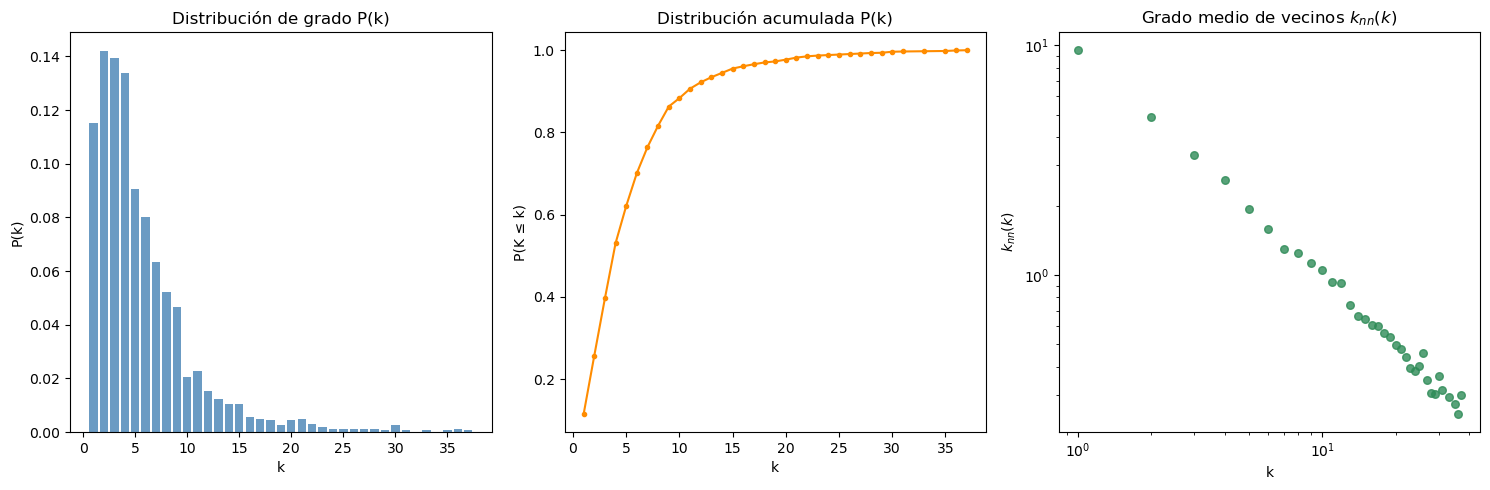

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# --- P(k): histograma de grados ---
k_max = degrees_cm.max()

# Conteo de ocurrencias de cada grado
pk_count_cm = np.zeros(k_max + 1, dtype=int)
for d in degrees_cm:
    pk_count_cm[d] += 1

# P(k) normalizado
pk_cm = pk_count_cm / N

# P(k) acumulado: P(K <= k)
pk_cum = np.zeros(k_max + 1, dtype=float)
for k in range(k_max + 1):
    pk_cum[k] = pk_cum[k-1] + pk_cm[k] if k > 0 else pk_cm[0]

# --- k_nn(k): grado medio de los vecinos de nodos con grado k ---
k_nn = np.zeros(k_max + 1, dtype=float)

for i in range(N):
    ki = degrees_cm[i]
    if ki == 0:
        continue
    # Contribución de cada vecino al k_nn(ki)
    # Normalizado por ki (grado del nodo) y por pk_count_cm[ki] (nodos en clase k)
    for pos in range(ptr1_cm[i], ptr1_cm[i] + ki):
        j = V_cm[pos]
        kj = degrees_cm[j]
        k_nn[ki] += kj / (ki * pk_count_cm[ki])

# --- Resultados ---
print(f"{'k':>6}  {'P(k)':>10}  {'P_cum(k)':>10}  {'k_nn(k)':>10}")
print("-" * 45)
for k in range(k_max + 1):
    if pk_cm[k] > 0:
        print(f"{k:>6}  {pk_cm[k]:>10.6f}  {pk_cum[k]:>10.6f}  {k_nn[k]:>10.4f}")

# --- Plots ---
ks = np.where(pk_cm > 0)[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# P(k)
axes[0].bar(ks, pk_cm[ks], color="steelblue", alpha=0.8)
axes[0].set_xlabel("k")
axes[0].set_ylabel("P(k)")
axes[0].set_title("Distribución de grado P(k)")

# P(k) acumulado
axes[1].plot(ks, pk_cum[ks], color="darkorange", marker="o", markersize=3)
axes[1].set_xlabel("k")
axes[1].set_ylabel("P(K ≤ k)")
axes[1].set_title("Distribución acumulada P(k)")

# k_nn(k)
ks_nn = np.where(k_nn > 0)[0]
axes[2].scatter(ks_nn, k_nn[ks_nn]/ks_nn, color="seagreen", alpha=0.8, s=30)
axes[2].set_xlabel("k")
axes[2].set_ylabel("$k_{nn}(k)$")
axes[2].set_title("Grado medio de vecinos $k_{nn}(k)$")
axes[2].set_xscale("log")
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig("pk_knn.png", dpi=150, bbox_inches="tight")
plt.show()

Coeficiente de clustering medio: 0.006343

     k        c(k)     N_k
----------------------------
     1    0.000000     186
     2    0.004367     229
     3    0.004444     225
     4    0.009259     216
     5    0.006164     146
     6    0.008786     129
     7    0.005602     102
     8    0.008929      84
     9    0.011481      75
    10    0.008081      33
    11    0.010811      37
    12    0.012121      25
    13    0.007051      20
    14    0.004525      17
    15    0.010084      17
    16    0.009259       9
    17    0.011949       8
    18    0.007470       7
    19    0.007310       4
    20    0.008271       7
    21    0.005952       8
    22    0.011255       5
    23    0.006588       3
    24    0.005435       2
    25    0.013333       2
    26    0.020000       2
    27    0.011396       2
    28    0.003968       2
    29    0.012315       1
    30    0.011494       4
    31    0.006452       1
    33    0.003788       1
    35    0.013445       1
    36    

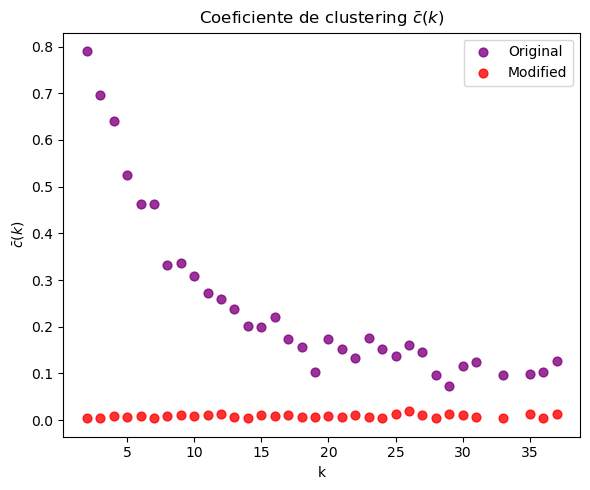

In [84]:
# --- Clustering coefficient c(k) según la fórmula de la imagen ---
# c(k) = 1 / (k*(k-1)*N_k) * sum_{i in Y(k)} 2*T_i

ck_cm = np.zeros(k_max + 1, dtype=float)

for i in range(N):  # loop 1: sobre cada nodo
    neighbors_list = list(set(V_cm[ptr1_cm[i] : ptr1_cm[i] + degrees_cm[i]]))
    ki = len(neighbors_list)

    if ki < 2:
        continue

    # Precalcular conjuntos de vecinos de cada vecino de i
    neighbors_j_sets = {
        j: set(V_cm[ptr1_cm[j] : ptr1_cm[j] + degrees_cm[j]])
        for j in neighbors_list
    }

    triangles = 0
    for a in range(ki):             # loop 2: primer vecino j
        j = neighbors_list[a]
        for b in range(a + 1, ki):  # loop 3: segundo vecino l
            l = neighbors_list[b]
            if l in neighbors_j_sets[j]:
                triangles += 1

    # Acumular 2*T_i en c(k); el denominador k*(k-1)*N_k se aplica al final
    ck_cm[degrees_cm[i]] += 2 * triangles

# Normalizar c(k) por k*(k-1)*N_k
for k in range(2, k_max + 1):
    if pk_count_cm[k] > 0:
        ck_cm[k] /= k * (k - 1) * pk_count_cm[k]

# Clustering medio global: c_bar = sum_k P(k) * c(k)
avg_cc_cm = sum(pk[k] * ck_cm[k] for k in range(k_max + 1))
print(f"Coeficiente de clustering medio: {avg_cc_cm:.6f}")

# --- Resultados por clase de grado ---
print(f"\n{'k':>6}  {'c(k)':>10}  {'N_k':>6}")
print("-" * 28)
for k in range(k_max + 1):
    if pk_cm[k] > 0:
        print(f"{k:>6}  {ck_cm[k]:>10.6f}  {pk_count[k]:>6}")

# --- Plot ---
ks_ck = np.where(ck_cm > 0)[0]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ks_ck, ck[ks_ck], color="purple", alpha=0.8, s=40, label="Original")
ax.scatter(ks_ck, ck_cm[ks_ck], color="red", alpha=0.8, s=40, label="Modified")
ax.set_xlabel("k")
ax.set_ylabel(r"$\bar{c}(k)$")
ax.set_title(r"Coeficiente de clustering $\bar{c}(k)$")
ax.legend()
plt.tight_layout()
plt.savefig("ck.png", dpi=150, bbox_inches="tight")
plt.show()

In [92]:
def compute_pk_knn(degrees, V, ptr1, N):
    k_max = degrees.max()
    pk_count = np.zeros(k_max + 1, dtype=int)
    for d in degrees:
        pk_count[d] += 1
    pk = pk_count / N

    pk_cum = np.zeros(k_max + 1, dtype=float)
    for k in range(k_max + 1):
        pk_cum[k] = pk_cum[k-1] + pk[k] if k > 0 else pk[0]

    k_nn = np.zeros(k_max + 1, dtype=float)
    for i in range(N):
        ki = degrees[i]
        if ki == 0:
            continue
        for pos in range(ptr1[i], ptr1[i] + ki):
            j = V[pos]
            kj = degrees[j]
            k_nn[ki] += kj / (ki * pk_count[ki])

    return k_max, pk_count, pk, pk_cum, k_nn


def compute_ck(degrees, V, ptr1, N, k_max, pk_count, pk):
    ck = np.zeros(k_max + 1, dtype=float)

    for i in range(N):
        neighbors_list = list(set(V[ptr1[i] : ptr1[i] + degrees[i]]))
        ki = len(neighbors_list)
        if ki < 2:
            continue

        neighbors_j_sets = {
            j: set(V[ptr1[j] : ptr1[j] + degrees[j]])
            for j in neighbors_list
        }

        triangles = 0
        for a in range(ki):
            j = neighbors_list[a]
            for b in range(a + 1, ki):
                l = neighbors_list[b]
                if l in neighbors_j_sets[j]:
                    triangles += 1

        ck[degrees[i]] += 2 * triangles

    for k in range(2, k_max + 1):
        if pk_count[k] > 0:
            ck[k] /= k * (k - 1) * pk_count[k]

    avg_cc = sum(pk[k] * ck[k] for k in range(k_max + 1))
    return ck, avg_cc


# --- 100 realizaciones CM ---
results = []  # guardará (k_nn, ck, avg_cc) de cada realización

avg_ccs = []
avg_knns = []
ck_list = []

for r in range(100):
    _, _, degrees_r, ptr1_r, V_r = generate_cm_network("voles_giant.edges")
    N_r = len(degrees_r)

    k_max_r, pk_count_r, pk_r, pk_cum_r, k_nn_r = compute_pk_knn(degrees_r, V_r, ptr1_r, N_r)
    ck_r, avg_cc_r = compute_ck(degrees_r, V_r, ptr1_r, N_r, k_max_r, pk_count_r, pk_r)

    avg_ccs.append(avg_cc_r)
    avg_knns.append(k_nn_r)
    ck_list.append(ck_r)

    if r % 10 == 0:
        print(f"Realización {r:3d} | avg_cc = {avg_cc_r:.6f}")

print(f"\nClustering medio sobre 100 realizaciones: {np.mean(avg_ccs):.6f} ± {np.std(avg_ccs):.6f}")

# k_nn(k) medio sobre realizaciones (alinear vectores al mismo k_max)
k_max_global = max(len(k) for k in avg_knns)
ck_matrix = np.zeros((100, k_max_global))
for r, ck_r in enumerate(ck_list):
    ck_matrix[r, :len(ck_r)] = ck_r
ck_mean = ck_matrix.mean(axis=0)
ck_std  = ck_matrix.std(axis=0)
knn_matrix = np.zeros((100, k_max_global))
for r, k_nn_r in enumerate(avg_knns):
    knn_matrix[r, :len(k_nn_r)] = k_nn_r

knn_mean = knn_matrix.mean(axis=0)
knn_std  = knn_matrix.std(axis=0)

print(f"k_nn medio (k=1..5): {knn_mean[1:6]}")

Realización   0 | avg_cc = 0.009188
Realización  10 | avg_cc = 0.008524
Realización  20 | avg_cc = 0.007654
Realización  30 | avg_cc = 0.006631
Realización  40 | avg_cc = 0.007159
Realización  50 | avg_cc = 0.005773
Realización  60 | avg_cc = 0.009352
Realización  70 | avg_cc = 0.007741
Realización  80 | avg_cc = 0.007486
Realización  90 | avg_cc = 0.008858

Clustering medio sobre 100 realizaciones: 0.007714 ± 0.001139
k_nn medio (k=1..5): [10.04591398  9.92305677  9.9850963   9.95810185  9.94856164]


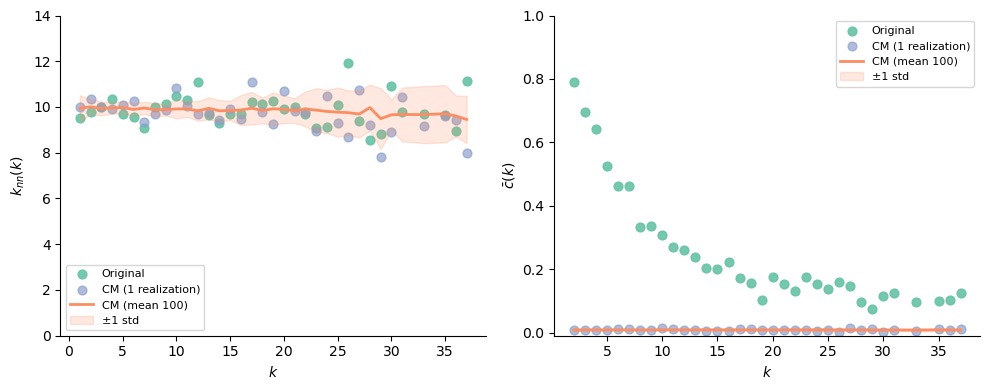

In [88]:
palette = plt.get_cmap("Set2")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- k_nn(k) ---
ks_orig = np.where(k_nn > 0)[0]
ks_cm   = np.where(knn_mean > 0)[0]
ks_cm_r = np.where(k_nn_r > 0)[0]

axes[0].scatter(ks_orig, k_nn[ks_orig], color=palette(0), s=40, alpha=0.9, label="Original")
axes[0].scatter(ks_cm_r, k_nn_r[ks_cm_r], color=palette(2), s=40, alpha=0.7, label="CM (1 realization)")
axes[0].plot(ks_cm, knn_mean[ks_cm], color=palette(1), linewidth=2, label="CM (mean 100)")
axes[0].fill_between(ks_cm,
                     knn_mean[ks_cm] - knn_std[ks_cm],
                     knn_mean[ks_cm] + knn_std[ks_cm],
                     color=palette(1), alpha=0.2, label="±1 std")
axes[0].set_xlabel("$k$")
axes[0].set_ylabel("$k_{nn}(k)$")
axes[0].set_ylim(0, 14)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].legend(fontsize=8)

# --- c(k) ---
ks_ck_orig = np.where(ck > 0)[0]
ks_ck_cm   = np.where(ck_mean > 1e-10)[0]
ks_ck_cm_r = np.where(ck_r > 0)[0]

axes[1].scatter(ks_ck_orig, ck[ks_ck_orig], color=palette(0), s=40, alpha=0.9, label="Original")
axes[1].scatter(ks_ck_cm_r, ck_r[ks_ck_cm_r], color=palette(2), s=40, alpha=0.7, label="CM (1 realization)")
axes[1].plot(ks_ck_cm, ck_mean[ks_ck_cm], color=palette(1), linewidth=2, label="CM (mean 100)")
axes[1].fill_between(ks_ck_cm,
                     ck_mean[ks_ck_cm] - ck_std[ks_ck_cm],
                     ck_mean[ks_ck_cm] + ck_std[ks_ck_cm],
                     color=palette(1), alpha=0.2, label="±1 std")
axes[1].set_xlabel("$k$")
axes[1].set_ylabel(r"$\bar{c}(k)$")
axes[1].set_ylim(-0.01, 1)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("comparison_original_vs_cm.png", dpi=150, bbox_inches="tight")
plt.show()

Número de comunidades: 19

Modularidad: 0.4079


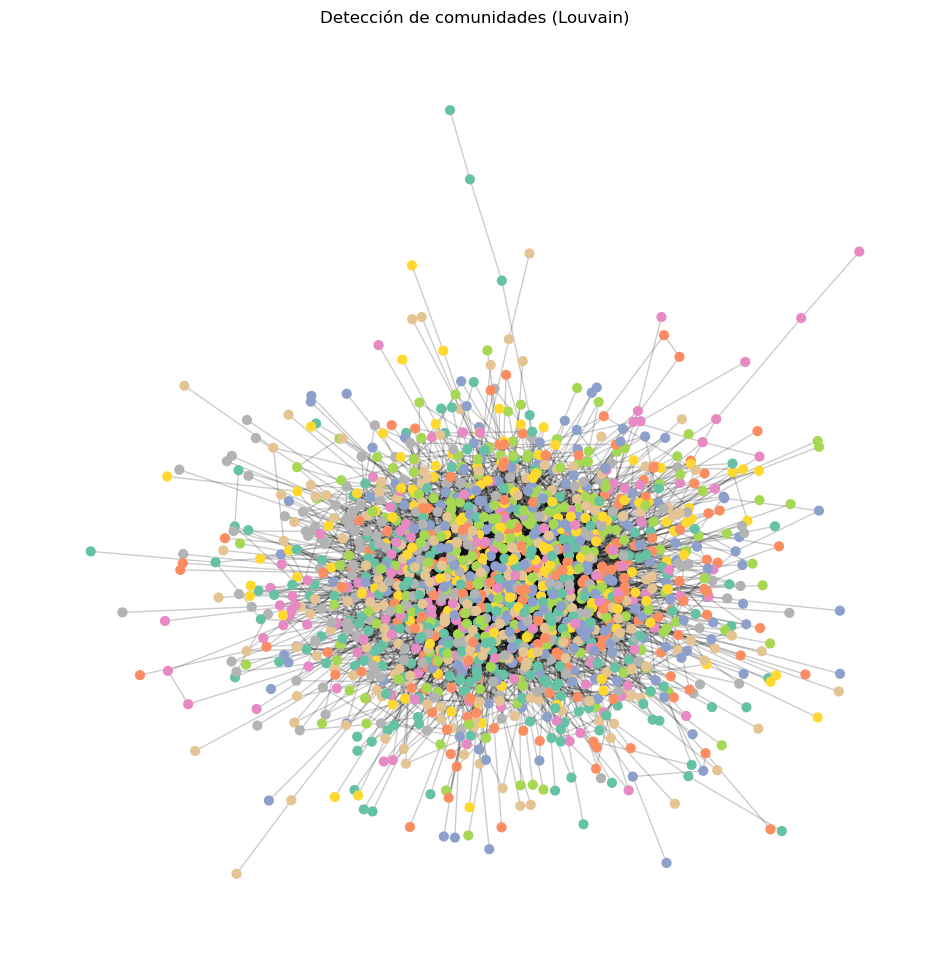

In [94]:
# partition: diccionario nodo -> comunidad
partition_louvain = community_louvain.best_partition(G_cm)

# número de comunidades
num_louvain = len(set(partition_louvain.values()))

print("Número de comunidades:", num_louvain)

mod_louvain = community_louvain.modularity(partition_louvain, G_cm)

print(f"\nModularidad: {mod_louvain:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

# layout del grafo
pos = nx.spring_layout(G_cm, seed=42)

# colores por comunidad
communities = [partition_louvain[node] for node in G_cm.nodes()]

nx.draw_networkx_nodes(
    G_cm,
    pos,
    node_size=40,
    node_color=communities,
    cmap=plt.cm.Set2
)

nx.draw_networkx_edges(
    G_cm,
    pos,
    alpha=0.2
)

plt.title("Detección de comunidades (Louvain)")
plt.axis("off")
plt.show()

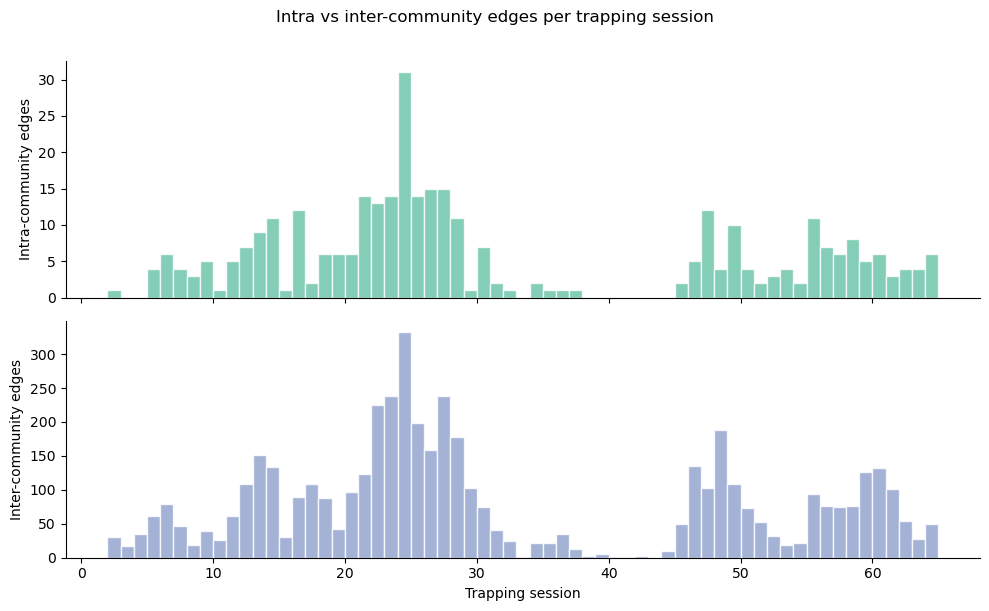

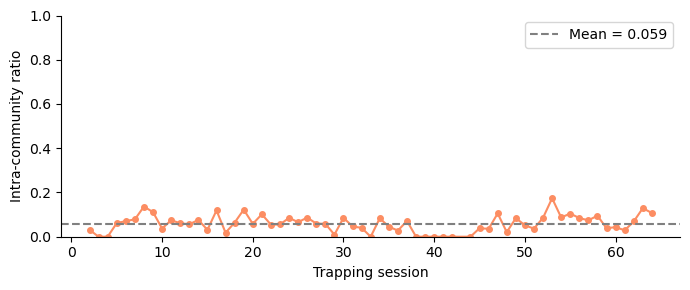

In [102]:
import pandas as pd
from collections import defaultdict

# Leer archivo original con timestamps
df = pd.read_csv("mammalia-voles-bhp-trapping.edges", sep=" ", header=None,
                 names=["source", "target", "weight", "time"])

# Para cada arista, ver si los dos nodos están en la misma comunidad
# y en qué sesión ocurrió el contacto
same_comm = []
diff_comm = []

#eliminar filas con Nan
df = df.dropna(subset=["source", "target", "time"])

for _, row in df.iterrows():
    u, v, t = int(row["source"]), int(row["target"]), int(row["time"])
    # Solo considerar nodos que están en la componente gigante
    if u not in partition_louvain or v not in partition_louvain:
        continue
    if partition_louvain[u] == partition_louvain[v]:
        same_comm.append(t)
    else:
        diff_comm.append(t)

# Distribución temporal de aristas intra vs inter comunidad
t_min = df["time"].min()
t_max = df["time"].max()
bins = np.arange(t_min, t_max + 2)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].hist(same_comm, bins=bins, color=palette(0), alpha=0.8, edgecolor="white")
axes[0].set_ylabel("Intra-community edges")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].hist(diff_comm, bins=bins, color=palette(2), alpha=0.8, edgecolor="white")
axes[1].set_ylabel("Inter-community edges")
axes[1].set_xlabel("Trapping session")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("Intra vs inter-community edges per trapping session", y=1.01)
plt.tight_layout()
plt.savefig("temporal_communities.png", dpi=150, bbox_inches="tight")
plt.show()

# Ratio intra/(intra+inter) por sesión
intra_per_session = defaultdict(int)
inter_per_session = defaultdict(int)

for t in same_comm:
    intra_per_session[t] += 1
for t in diff_comm:
    inter_per_session[t] += 1

sessions = sorted(set(list(intra_per_session.keys()) + list(inter_per_session.keys())))
ratios_per_session = []
for t in sessions:
    total = intra_per_session[t] + inter_per_session[t]
    ratios_per_session.append(intra_per_session[t] / total if total > 0 else 0)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(sessions, ratios_per_session, color=palette(1), marker="o", markersize=4)
ax.axhline(np.mean(ratios_per_session), color="gray", linestyle="--",
           label=f"Mean = {np.mean(ratios_per_session):.3f}")
ax.set_xlabel("Trapping session")
ax.set_ylabel("Intra-community ratio")
ax.set_ylim(0, 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig("temporal_ratio.png", dpi=150, bbox_inches="tight")
plt.show()